# Testing Qpr calculations when elongating the grating

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')

import torch

import autolib 
import fom
from parameters import D1_ND, Parameters
from twobox import TwoBox
from ilic import *

npa = autolib.AutoLib('torch')
npaa = autolib.AutoLib('autograd')

# Ilic grating

In [2]:
 ## Ilic
wavelength      = 1.5 #/ D1_ND(1.2/100)
grating_pitch   = 1.8 / wavelength
grating_depth   = 0.5 / wavelength
box1_width      = 0.15 * grating_pitch
box2_width      = 0.35 * grating_pitch
box_centre_dist = 0.60 * grating_pitch
box1_eps        = 3.5**2 
box2_eps        = 3.5**2
gaussian_width  = 2* 10   # 2.7180049942915896 * 10
substrate_depth = 0.5 / wavelength
substrate_eps   = 1.45**2

wavelength      = 1.
angle           = 0.
Nx              = 300
numG            = 12
Qabs            = np.inf

gratingGRCWA = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
                 gaussian_width, substrate_depth, substrate_eps,
                 wavelength, angle, Nx, numG, Qabs, RCWA_engine='GRCWA')
numGTorcwa = numG
gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
                 gaussian_width, substrate_depth, substrate_eps,
                 wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)

# Qpr2 and elongation testing

In [3]:
from copy import deepcopy as deepcopy
from flex import Qpr2_elongated, dQpr2_dscale

box_centre_dist = 0.15*grating_pitch
gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
                 gaussian_width, substrate_depth, substrate_eps,
                 wavelength, angle, Nx, 12, Qabs, RCWA_engine='TORCWA', torcwa_edge_sharpness=50)

Qpr2_base = gratingTorcwa.Q()[1]
print('Qpr2 base = ',Qpr2_base)
print(gratingTorcwa.params)

scale = torch.tensor(1.)
Qpr2_unscaled = Qpr2_elongated(gratingTorcwa, scale)
print('Qpr2 unscaled = ',Qpr2_unscaled)
print(gratingTorcwa.params)

# _ = gratingTorcwa.show_permittivity()

PDQpr2_PDscale = dQpr2_dscale(gratingTorcwa, scale)
print('Automatic diff dQpr2/dscale at scale=1 = ',PDQpr2_PDscale)

h = 1e-4
scale_plus = 1. + h
Qpr2_plus = Qpr2_elongated(gratingTorcwa, scale_plus)
scale_minus = 1. - h
Qpr2_minus = Qpr2_elongated(gratingTorcwa, scale_minus)
PDQpr2_PDscale_FD = (Qpr2_plus - Qpr2_minus) / (2.*h)
print('Finite difference dQpr2/dscale at scale=1 = ',PDQpr2_PDscale_FD)

scale=1.1
Qpr2_scaled = Qpr2_elongated(gratingTorcwa, scale)
print('Qpr2 scaled = ',Qpr2_scaled)
print(gratingTorcwa.params)

# _ = gratingTorcwa.show_permittivity()

Qpr2 base =  tensor(-0.0912, dtype=torch.float64, grad_fn=<SelectBackward0>)
[tensor(1.2000, dtype=torch.float64, requires_grad=True), tensor(0.3333, dtype=torch.float64, requires_grad=True), tensor(0.1800, dtype=torch.float64, requires_grad=True), tensor(0.4200, dtype=torch.float64, requires_grad=True), tensor(0.1800, dtype=torch.float64, requires_grad=True), tensor(12.2500, dtype=torch.float64, requires_grad=True), tensor(12.2500, dtype=torch.float64, requires_grad=True), tensor(20., dtype=torch.float64, requires_grad=True), tensor(0.3333, dtype=torch.float64, requires_grad=True), tensor(2.1025, dtype=torch.float64, requires_grad=True)]
Qpr2 unscaled =  tensor(-0.0912, dtype=torch.float64, grad_fn=<SelectBackward0>)
[tensor(1.2000, dtype=torch.float64, requires_grad=True), tensor(0.3333, dtype=torch.float64, requires_grad=True), tensor(0.1800, dtype=torch.float64, requires_grad=True), tensor(0.4200, dtype=torch.float64, requires_grad=True), tensor(0.1800, dtype=torch.float64, require

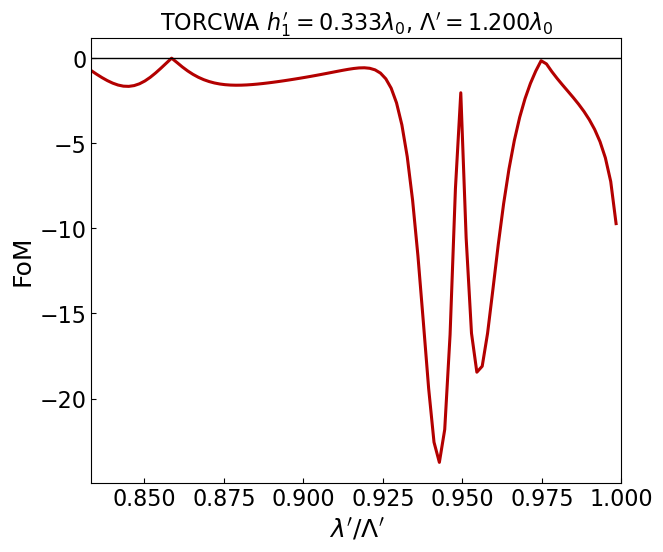

In [7]:
final_speed = 15.
# average_kpr = fom.multifom_minimum_adp(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=0.1, return_grad=False)
# print(f'Adp kpr min after speed {final_speed}%c = {average_kpr}')

# average_kpr = fom.multifom_minimum(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=100, return_grad=True)
# print(f'Man kpr min after speed {final_speed}%c = {average_kpr}')

_ = gratingTorcwa.show_FOM_spectrum(fom.monofom_elongation, angle=0., wavelength_range=(1.,1.2), num_plot_points=100)

### Minimum kpr figure of merit vs number of samples

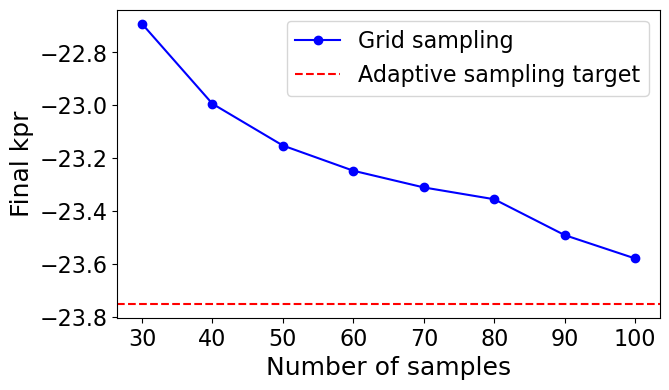

In [6]:
final_speed = 15.
n_samples = np.arange(30,110,10)
# n_samples = np.arange(30,70,10)
target_kpr = fom.multifom_minimum_adp(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=0.01, return_grad=False)

kprs = np.zeros(len(n_samples))
for idx, n in enumerate(n_samples):
    kprs[idx] = fom.multifom_minimum(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=n, return_grad=False)

fig, ax = plt.subplots(1,figsize=(7,4))
ax.plot(n_samples, kprs, color="blue", marker='o', label='Grid sampling')
ax.axhline(y=target_kpr, color='red', linestyle='--', label='Adaptive sampling target')
ax.set(xlabel='Number of samples', ylabel='Final kpr')
ax.set_xticks(n_samples)
ax.legend()